# HW4 Part 5: Monitoring & Drift Detection

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

np.random.seed(42)
print('Imports OK')

Imports OK


## 5A. Production Data Simulation

In [2]:
# Load training data and trained model
df = pd.read_csv('ml_ready_df.csv')
model = joblib.load('model/model.pkl')

TARGET = 'is_positive_review'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

# Reference distribution = full training data (used for PSI/KS baseline)
reference = df[FEATURE_COLS].copy()

print(f'Loaded {len(df):,} training records')
print(f'Features: {len(FEATURE_COLS)}')

Loaded 117,437 training records
Features: 16


In [3]:
RECORDS_PER_MONTH = 3000
NUMERIC_FEATURES  = [
    'delivery_days', 'delivery_vs_estimated', 'price', 'freight_value',
    'seller_score', 'num_previous_sales', 'cust_reviews', 'freight_ratio',
    'num_previous_reviews', 'num_items', 'same_state', 'is_repeat_customer',
    'delivery_missing'
]
CAT_FEATURES = ['product_category_name_english', 'seller_state', 'payment_type']

monthly_data = []

for month in range(1, 7):
    # Sample 3,000 records from the full dataset
    sample = df.sample(n=RECORDS_PER_MONTH, random_state=month).copy()
    sample['month'] = month

    # ── Months 1–3: stable — add ±5% noise to numeric features ────────────────
    if month <= 3:
        for col in NUMERIC_FEATURES:
            noise = np.random.uniform(-0.05, 0.05, size=len(sample))
            sample[col] = sample[col] * (1 + noise)

    # ── Months 4–6: progressive drift ─────────────────────────────────────────
    else:
        drift_level = month - 3   # 1, 2, or 3

        # delivery_days: +2 days per drift level
        sample['delivery_days'] = sample['delivery_days'] + (2 * drift_level)

        # freight_value: +15% / +30% / +50%
        freight_increase = {1: 1.15, 2: 1.30, 3: 1.50}[drift_level]
        sample['freight_value'] = sample['freight_value'] * freight_increase

        # freight_ratio: recompute after freight_value change
        sample['freight_ratio'] = sample['freight_value'] / (sample['price'] + 1e-9)

        # product_category: boost electronics share by 10%/15%/20%
        boost = {1: 0.10, 2: 0.15, 3: 0.20}[drift_level]
        n_to_flip = int(len(sample) * boost)
        non_elec_idx = sample[sample['product_category_name_english'] != 'electronics'].index
        flip_idx = np.random.choice(non_elec_idx, size=min(n_to_flip, len(non_elec_idx)), replace=False)
        sample.loc[flip_idx, 'product_category_name_english'] = 'electronics'

        # Label flip: 5% positive → negative (concept drift)
        positive_idx = sample[sample[TARGET] == 1].index
        flip_n = int(len(positive_idx) * 0.05)
        flip_label_idx = np.random.choice(positive_idx, size=flip_n, replace=False)
        sample.loc[flip_label_idx, TARGET] = 0

        # Also add ±5% noise on top of drift
        for col in NUMERIC_FEATURES:
            noise = np.random.uniform(-0.05, 0.05, size=len(sample))
            sample[col] = sample[col] * (1 + noise)

    monthly_data.append(sample)
    print(f'Month {month}: {len(sample):,} records  |  '
          f'positive rate: {sample[TARGET].mean():.3f}  |  '
          f'avg delivery_days: {sample["delivery_days"].mean():.1f}  |  '
          f'avg freight_value: {sample["freight_value"].mean():.2f}')

production_df = pd.concat(monthly_data, ignore_index=True)
print(f'\nTotal production records: {len(production_df):,}')

Month 1: 3,000 records  |  positive rate: 0.741  |  avg delivery_days: 12.3  |  avg freight_value: 20.31
Month 2: 3,000 records  |  positive rate: 0.737  |  avg delivery_days: 12.2  |  avg freight_value: 20.06
Month 3: 3,000 records  |  positive rate: 0.760  |  avg delivery_days: 11.8  |  avg freight_value: 19.97
Month 4: 3,000 records  |  positive rate: 0.722  |  avg delivery_days: 13.9  |  avg freight_value: 23.34
Month 5: 3,000 records  |  positive rate: 0.728  |  avg delivery_days: 15.8  |  avg freight_value: 25.40
Month 6: 3,000 records  |  positive rate: 0.712  |  avg delivery_days: 18.0  |  avg freight_value: 29.43

Total production records: 18,000


## 5B. Statistical Drift Detection

In [4]:
# Features to monitor with PSI and KS test
DRIFT_FEATURES = ['delivery_days', 'freight_value', 'price', 'delivery_vs_estimated', 'freight_ratio']

def compute_psi(reference_col, production_col, n_bins=10):
    """PSI = Σ (actual% - expected%) × ln(actual% / expected%)
    Uses equal-width bins based on reference distribution.
    Adds small constant to avoid division by zero.
    """
    eps = 0.0001
    # Build bins from reference
    min_val = min(reference_col.min(), production_col.min())
    max_val = max(reference_col.max(), production_col.max())
    bins = np.linspace(min_val, max_val, n_bins + 1)

    ref_counts, _ = np.histogram(reference_col, bins=bins)
    prod_counts, _ = np.histogram(production_col, bins=bins)

    ref_pct  = (ref_counts  / len(reference_col))  + eps
    prod_pct = (prod_counts / len(production_col)) + eps

    psi = np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct))
    return round(psi, 4)


# PSI table: features × months
psi_results = {}
for feat in DRIFT_FEATURES:
    psi_results[feat] = {}
    for month in range(1, 7):
        month_data = production_df[production_df['month'] == month][feat].dropna()
        ref_data   = reference[feat].dropna()
        psi_results[feat][f'Month {month}'] = compute_psi(ref_data, month_data)

psi_df = pd.DataFrame(psi_results).T
print('PSI Table (rows=features, cols=months):')
print(psi_df.to_string())

PSI Table (rows=features, cols=months):
                       Month 1  Month 2  Month 3  Month 4  Month 5  Month 6
delivery_days           0.0032   0.0020   0.0025   0.0076   0.0426   0.1244
freight_value           0.0018   0.0023   0.0028   0.0168   0.0222   0.0480
price                   0.0016   0.0012   0.0016   0.0007   0.0032   0.0015
delivery_vs_estimated   0.0109   0.0024   0.0095   0.0058   0.0050   0.0070
freight_ratio           0.0000   0.0007   0.0003   0.0009   0.0012   0.0032


In [5]:
# KS Test: features × months
ks_results = []
for feat in DRIFT_FEATURES:
    ref_data = reference[feat].dropna()
    for month in range(1, 7):
        month_data = production_df[production_df['month'] == month][feat].dropna()
        ks_stat, p_value = stats.ks_2samp(ref_data, month_data)
        ks_results.append({
            'Feature': feat,
            'Month':   month,
            'KS Stat': round(ks_stat, 4),
            'p-value': round(p_value, 4),
            'Significant': '✓' if p_value < 0.05 else ''
        })

ks_df = pd.DataFrame(ks_results)
print('KS Test Results:')
print(ks_df.to_string(index=False))

KS Test Results:
              Feature  Month  KS Stat  p-value Significant
        delivery_days      1   0.0470   0.0000           ✓
        delivery_days      2   0.0482   0.0000           ✓
        delivery_days      3   0.0416   0.0001           ✓
        delivery_days      4   0.1790   0.0000           ✓
        delivery_days      5   0.3211   0.0000           ✓
        delivery_days      6   0.4271   0.0000           ✓
        freight_value      1   0.0342   0.0022           ✓
        freight_value      2   0.0318   0.0056           ✓
        freight_value      3   0.0425   0.0001           ✓
        freight_value      4   0.1710   0.0000           ✓
        freight_value      5   0.3394   0.0000           ✓
        freight_value      6   0.4501   0.0000           ✓
                price      1   0.0242   0.0654            
                price      2   0.0280   0.0204           ✓
                price      3   0.0175   0.3360            
                price      4   0.0326  

## 5C. Performance Monitoring

In [6]:
perf_results = []

for month in range(1, 7):
    month_df  = production_df[production_df['month'] == month]
    X_month   = month_df[FEATURE_COLS]
    y_true    = month_df[TARGET]

    y_pred  = model.predict(X_month)
    y_proba = model.predict_proba(X_month)[:, 1]

    perf_results.append({
        'Month':    month,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1':       round(f1_score(y_true, y_pred),       4),
        'AUC':      round(roc_auc_score(y_true, y_proba), 4),
    })

perf_df = pd.DataFrame(perf_results)
print('Monthly Performance Metrics:')
print(perf_df.to_string(index=False))

# Performance drop Month 1 → Month 6
f1_drop  = perf_df.iloc[0]['F1']  - perf_df.iloc[-1]['F1']
f1_pct   = f1_drop / perf_df.iloc[0]['F1'] * 100
auc_drop = perf_df.iloc[0]['AUC'] - perf_df.iloc[-1]['AUC']
auc_pct  = auc_drop / perf_df.iloc[0]['AUC'] * 100

print(f'\nPerformance Drop (Month 1 → Month 6):')
print(f'  F1  : {perf_df.iloc[0]["F1"]:.4f} → {perf_df.iloc[-1]["F1"]:.4f}  '
      f'(↓ {f1_drop:.4f}, {f1_pct:.1f}%)')
print(f'  AUC : {perf_df.iloc[0]["AUC"]:.4f} → {perf_df.iloc[-1]["AUC"]:.4f}  '
      f'(↓ {auc_drop:.4f}, {auc_pct:.1f}%)')

Monthly Performance Metrics:
 Month  Accuracy     F1    AUC
     1    0.8250 0.8826 0.8430
     2    0.8230 0.8815 0.8512
     3    0.8290 0.8877 0.8521
     4    0.7883 0.8560 0.7955
     5    0.7613 0.8359 0.7699
     6    0.7543 0.8266 0.7844

Performance Drop (Month 1 → Month 6):
  F1  : 0.8826 → 0.8266  (↓ 0.0560, 6.3%)
  AUC : 0.8430 → 0.7844  (↓ 0.0586, 7.0%)


## 5D. Monitoring Dashboard

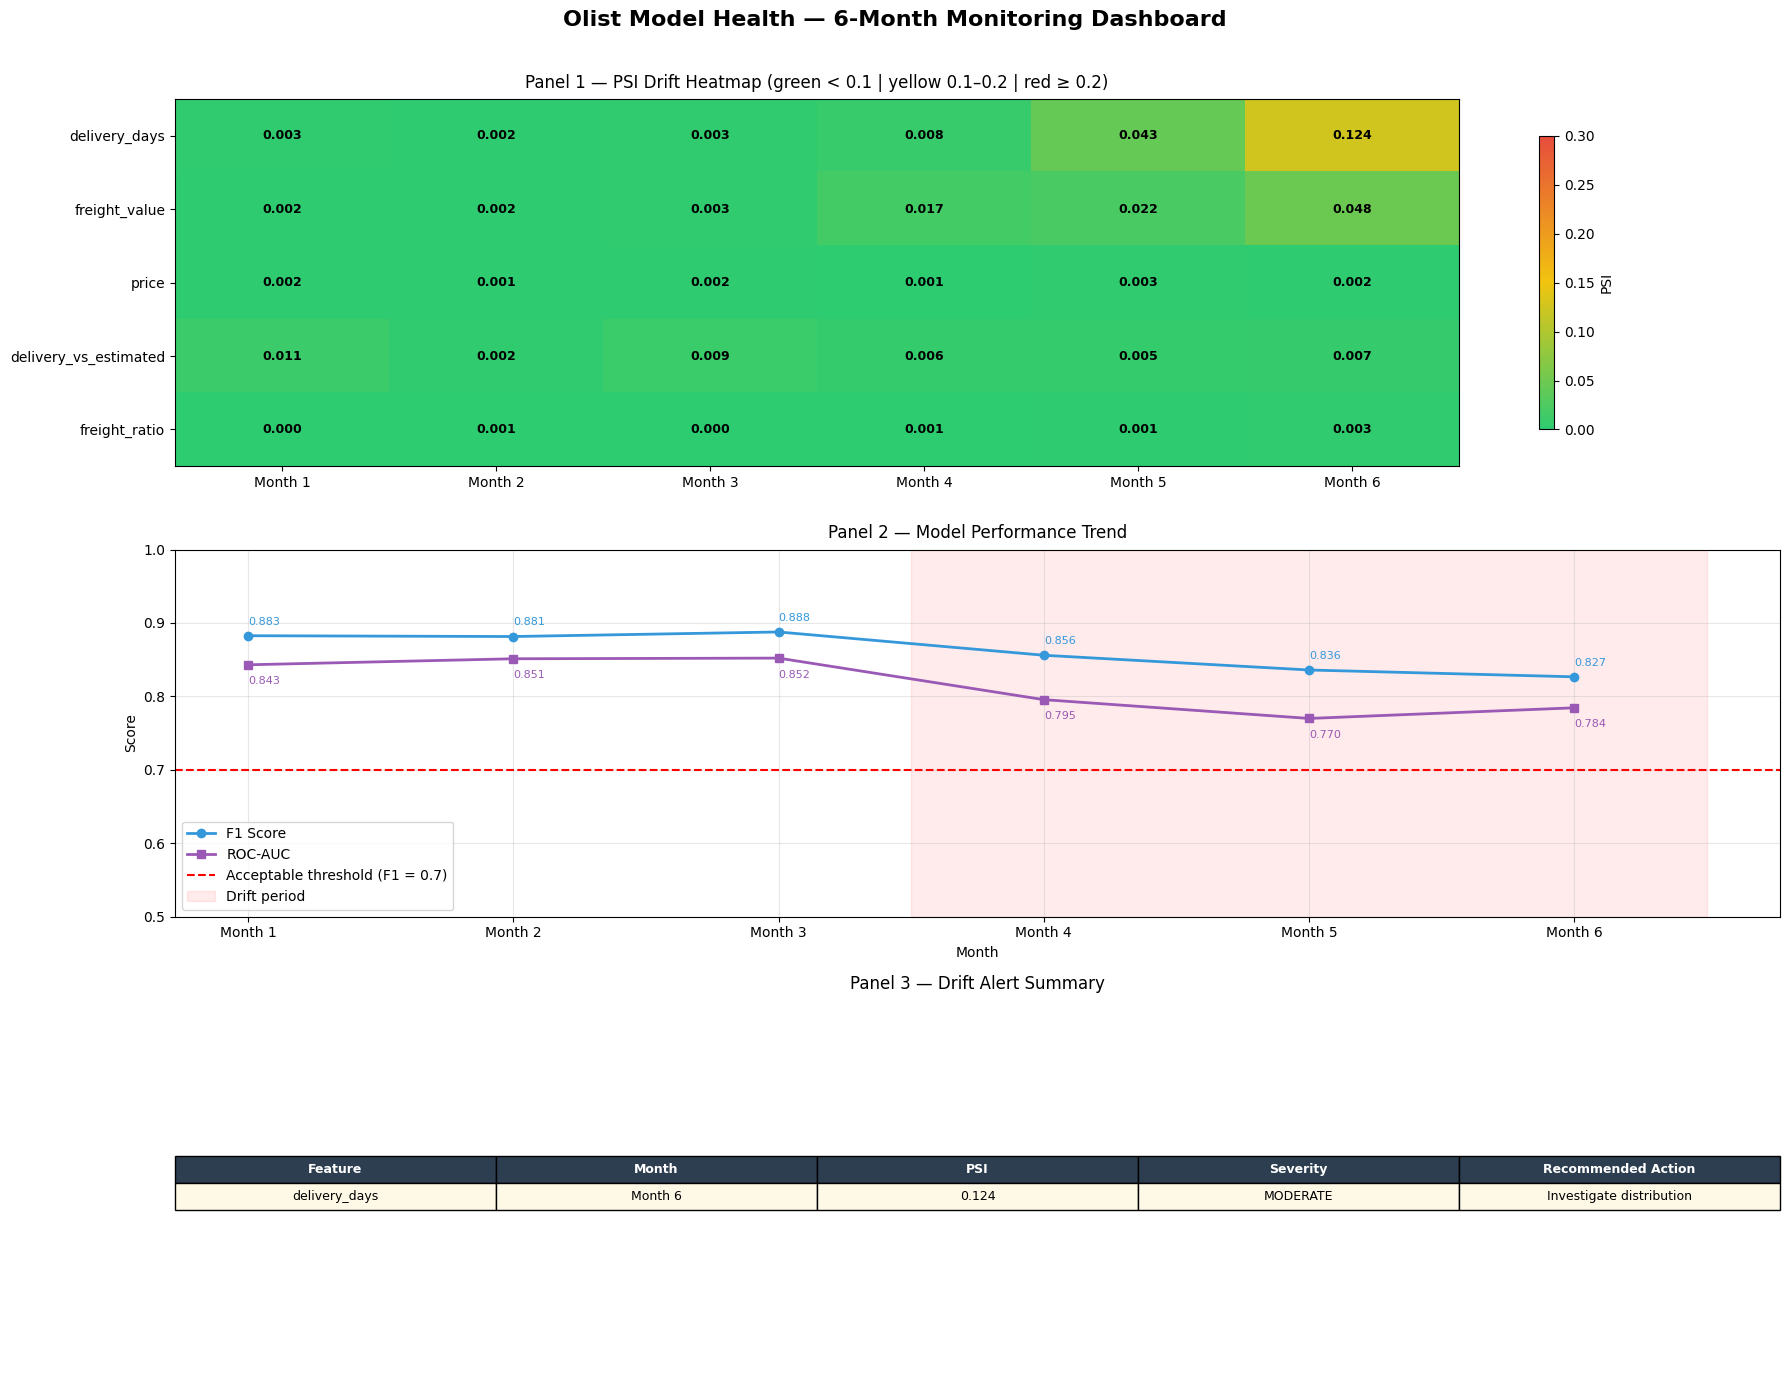

Dashboard saved to monitoring_dashboard.png


In [ ]:
THRESHOLD_F1 = 0.70  # "acceptable" performance threshold

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Olist Model Health — 6-Month Monitoring Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# ── Panel 1: Drift Heatmap ────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 1, 1)

psi_values = psi_df.values.astype(float)

# Custom colormap: green < 0.1, yellow 0.1–0.2, red >= 0.2
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'drift', ['#2ecc71', '#f1c40f', '#e74c3c'], N=256
)

im = ax1.imshow(psi_values, cmap=cmap, vmin=0, vmax=0.3, aspect='auto')
ax1.set_xticks(range(6))
ax1.set_xticklabels([f'Month {i+1}' for i in range(6)])
ax1.set_yticks(range(len(DRIFT_FEATURES)))
ax1.set_yticklabels(DRIFT_FEATURES)
ax1.set_title('Panel 1 — PSI Drift Heatmap (green < 0.1 | yellow 0.1–0.2 | red ≥ 0.2)',
              fontsize=12, pad=8)

# Annotate each cell with PSI value
for i in range(len(DRIFT_FEATURES)):
    for j in range(6):
        val = psi_values[i, j]
        color = 'white' if val >= 0.2 else 'black'
        ax1.text(j, i, f'{val:.3f}', ha='center', va='center',
                 fontsize=9, color=color, fontweight='bold')

plt.colorbar(im, ax=ax1, label='PSI', shrink=0.8)

# ── Panel 2: Performance Trend ────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 1, 2)
months = perf_df['Month'].tolist()

ax2.plot(months, perf_df['F1'],  marker='o', linewidth=2,
         color='#3498db', label='F1 Score')
ax2.plot(months, perf_df['AUC'], marker='s', linewidth=2,
         color='#9b59b6', label='ROC-AUC')
ax2.axhline(y=THRESHOLD_F1, color='red', linestyle='--', linewidth=1.5,
            label=f'Acceptable threshold (F1 = {THRESHOLD_F1})')
ax2.axvspan(3.5, 6.5, alpha=0.08, color='red', label='Drift period')

ax2.set_xlabel('Month')
ax2.set_ylabel('Score')
ax2.set_xticks(months)
ax2.set_xticklabels([f'Month {m}' for m in months])
ax2.set_ylim(0.5, 1.0)
ax2.legend(loc='lower left')
ax2.set_title('Panel 2 — Model Performance Trend', fontsize=12, pad=8)
ax2.grid(True, alpha=0.3)

# Annotate each point
for _, row in perf_df.iterrows():
    ax2.annotate(f"{row['F1']:.3f}", (row['Month'], row['F1']),
                 textcoords='offset points', xytext=(0, 8), fontsize=8, color='#3498db')
    ax2.annotate(f"{row['AUC']:.3f}", (row['Month'], row['AUC']),
                 textcoords='offset points', xytext=(0, -14), fontsize=8, color='#9b59b6')

# ── Panel 3: Alert Summary Table ──────────────────────────────────────────────
ax3 = fig.add_subplot(3, 1, 3)
ax3.axis('off')

# Build alert rows: PSI >= 0.1
alert_rows = []
for feat in DRIFT_FEATURES:
    for month_col in psi_df.columns:
        psi_val = psi_df.loc[feat, month_col]
        if psi_val >= 0.2:
            action = 'Action required — retrain'
            severity = 'HIGH'
        elif psi_val >= 0.1:
            action = 'Investigate distribution'
            severity = 'MODERATE'
        else:
            continue
        alert_rows.append([feat, month_col, f'{psi_val:.3f}', severity, action])

if not alert_rows:
    alert_rows = [['No alerts', '—', '—', '—', 'All features stable']]

col_labels = ['Feature', 'Month', 'PSI', 'Severity', 'Recommended Action']
table = ax3.table(
    cellText=alert_rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Color rows by severity
for i, row in enumerate(alert_rows):
    color = '#fadbd8' if row[3] == 'HIGH' else '#fef9e7'
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color)

# Header color
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax3.set_title('Panel 3 — Drift Alert Summary', fontsize=12, pad=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('monitoring_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 5E. Retraining Recommendation

The monitoring results show gradual but consistent model degradation beginning in Month 4. Among the five monitored features, only delivery_days crossed the moderate-drift threshold, reaching a PSI of 0.124 in Month 6 — the remaining features stayed well below 0.1 throughout the observation period. No features crossed the 0.2 significant-drift threshold. Despite the relatively modest feature drift, model performance declined steadily during the drift period: F1 dropped from 0.883 in Month 1 to 0.827 in Month 6 (absolute drop: 0.056, 6.3% decrease), and ROC-AUC fell from 0.843 to 0.784 (absolute drop: 0.059, 7.0% decrease). Both metrics remained above the 0.70 acceptable threshold throughout.
Based on this analysis, immediate retraining is not required, but proactive monitoring should continue. I recommend triggering a retraining review if any feature's PSI exceeds 0.2 for two consecutive months, or if F1 drops below 0.82 — a buffer that would have activated at Month 4 in this simulation. The retrained model should include a rolling 12-month window of production data, weighted toward recent months to reflect the shifting delivery_days distribution and higher freight_value levels observed in Months 4–6.